# DB2:RelE REMD Analysis

## Imports

In [2]:
%matplotlib inline
import os, sys
from collections import Counter

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.ndimage import gaussian_filter

import MDAnalysis as mda
from MDAnalysis.analysis import rms
from sklearn.cluster import KMeans


## Configuration

In [3]:
# ── Trajectory ───────────────────────────────────────────────────────────────
TRAJ_TOP = "DB2_bound_unbound_300K_stripped.pdb"
TRAJ_XTC = "DB2_bound_unbound_300K_stripped.xtc"

# ── References ───────────────────────────────────────────────────────────────
REF_ALONE       = "DB2_alone.pdb"   # unbound DB2 conformation
REF_BOUND       = "DB2_RelE.pdb"    # DB2:RelE complex
REF_BOUND_CHAIN = "A"

BACKBONE_SEL = "backbone"

# ── Region definitions (reference numbering, S = 1) ─────────────────────────
INTERFACE_RESIDS_REF = [3, 6, 10, 13, 14, 21, 22, 24, 39, 42, 43, 45, 46,
                         51, 60, 63, 64, 67]
CORE_START_REF       = 26

# ── Equilibration / clustering ──────────────────────────────────────────────
BURNIN_FRAMES = 5000
K_CHOSEN      = 6        # number of k-means clusters (final value from elbow analysis)

# ── Output ───────────────────────────────────────────────────────────────────
OUT_PREFIX = "remd"

# ── Constants ────────────────────────────────────────────────────────────────
kT = 0.592               # kcal/mol at 298 K

print("Config loaded.")


Config loaded.


## 1. Load references and trajectory


In [5]:
# ── Load references ─────────────────────────────────────────────────────────
ref_alone = mda.Universe(REF_ALONE)
ref_bound = mda.Universe(REF_BOUND)

# Detect chain selector for bound reference
BOUND_CHAIN_SEL = None
for kw in ["chainID", "segid"]:
    test = f"{BACKBONE_SEL} and {kw} {REF_BOUND_CHAIN}"
    if len(ref_bound.select_atoms(test)) > 0:
        BOUND_CHAIN_SEL = test
        break
assert BOUND_CHAIN_SEL, "Cannot select chain A from bound reference"
print(f"Bound chain selector: {BOUND_CHAIN_SEL}")

# ── Load trajectory ─────────────────────────────────────────────────────────
u = mda.Universe(TRAJ_TOP, TRAJ_XTC)
print(f"Trajectory: {len(u.trajectory)} frames, {len(u.atoms)} atoms")

# ── Detect N-terminal Met offset ────────────────────────────────────────────
traj_resids = sorted(u.select_atoms(BACKBONE_SEL).residues.resids)
ref_resids  = sorted(ref_alone.select_atoms(BACKBONE_SEL).residues.resids)
traj_first_resname = u.select_atoms(
    f"{BACKBONE_SEL} and resid {traj_resids[0]}").residues[0].resname

TRAJ_OFFSET = 0
if len(traj_resids) == len(ref_resids) + 1 and traj_first_resname == "MET":
    TRAJ_OFFSET = 1
    print(f"Extra N-terminal Met detected (offset = {TRAJ_OFFSET})")
else:
    print(f"Trajectory and reference numbering match (offset = 0)")


Bound chain selector: backbone and chainID A
Trajectory: 50000 frames, 1231 atoms
Extra N-terminal Met detected (offset = 1)


## 2. Build selections and extract reference coordinates

Six regions are defined: `all`, `core`, `nterm`, `iface`, `noniface`, `core_iface`. The notebook only plots `all`, `core`, and `nterm`, but having all six available makes it easy to extend later without re-running the trajectory loop.

In [6]:
# Trajectory selection bounds (with offset applied)
traj_start = traj_resids[0] + TRAJ_OFFSET
traj_end   = traj_resids[-1]
ref_start, ref_end = ref_resids[0], ref_resids[-1]
nterm_ref_end      = CORE_START_REF - 1

# ── Region-keyed selection strings ──────────────────────────────────────────
iface_traj_str     = " ".join(str(r + TRAJ_OFFSET) for r in INTERFACE_RESIDS_REF)
iface_ref_str      = " ".join(str(r) for r in INTERFACE_RESIDS_REF)
core_iface_traj    = [r + TRAJ_OFFSET for r in INTERFACE_RESIDS_REF if r >= CORE_START_REF]
core_iface_ref_str = " ".join(str(r) for r in INTERFACE_RESIDS_REF if r >= CORE_START_REF)

SELS = {
    "traj_all":        f"{BACKBONE_SEL} and resid {traj_start}:{traj_end}",
    "traj_iface":      f"{BACKBONE_SEL} and resid {iface_traj_str}",
    "traj_noniface":   f"{BACKBONE_SEL} and resid {traj_start}:{traj_end} and not resid {iface_traj_str}",
    "traj_core":       f"{BACKBONE_SEL} and resid {CORE_START_REF + TRAJ_OFFSET}:{traj_end}",
    "traj_core_iface": f"{BACKBONE_SEL} and resid {' '.join(str(r) for r in core_iface_traj)}",
    "traj_nterm":      f"{BACKBONE_SEL} and resid {traj_start}:{CORE_START_REF - 1 + TRAJ_OFFSET}",
}

REF_SELS = {
    "all":        (f"{BACKBONE_SEL} and resid {ref_start}:{ref_end}",
                   f"{BOUND_CHAIN_SEL} and resid {ref_start}:{ref_end}"),
    "iface":      (f"{BACKBONE_SEL} and resid {iface_ref_str}",
                   f"{BOUND_CHAIN_SEL} and resid {iface_ref_str}"),
    "noniface":   (f"{BACKBONE_SEL} and resid {ref_start}:{ref_end} and not resid {iface_ref_str}",
                   f"{BOUND_CHAIN_SEL} and resid {ref_start}:{ref_end} and not resid {iface_ref_str}"),
    "core":       (f"{BACKBONE_SEL} and resid {CORE_START_REF}:{ref_end}",
                   f"{BOUND_CHAIN_SEL} and resid {CORE_START_REF}:{ref_end}"),
    "core_iface": (f"{BACKBONE_SEL} and resid {core_iface_ref_str}",
                   f"{BOUND_CHAIN_SEL} and resid {core_iface_ref_str}"),
    "nterm":      (f"{BACKBONE_SEL} and resid {ref_start}:{nterm_ref_end}",
                   f"{BOUND_CHAIN_SEL} and resid {ref_start}:{nterm_ref_end}"),
}

TRAJ_SEL_MAP = {"all": "traj_all", "iface": "traj_iface", "noniface": "traj_noniface",
                "core": "traj_core", "core_iface": "traj_core_iface", "nterm": "traj_nterm"}

# ── Extract reference coordinates and verify atom counts ────────────────────
refs = {}
for region, (ra_sel, rb_sel) in REF_SELS.items():
    refs[f"alone_{region}"] = ref_alone.select_atoms(ra_sel).positions.copy()
    refs[f"bound_{region}"] = ref_bound.select_atoms(rb_sel).positions.copy()
    rr = rms.rmsd(refs[f"alone_{region}"], refs[f"bound_{region}"],
                  center=True, superposition=True)
    nt = len(u.select_atoms(SELS[TRAJ_SEL_MAP[region]]))
    na = len(refs[f"alone_{region}"])
    nb = len(refs[f"bound_{region}"])
    print(f"  {region:<10}: traj={nt}, alone={na}, bound={nb}, "
          f"alone↔bound RMSD = {rr:.2f} Å")
    assert nt == na == nb, f"Atom count mismatch in {region}!"

REGIONS = list(REF_SELS.keys())

# ── Equilibration mask ──────────────────────────────────────────────────────
n_frames = len(u.trajectory)
eq_mask  = np.arange(n_frames) >= BURNIN_FRAMES
n_eq     = int(eq_mask.sum())
print(f"\nFrames: {n_frames} total, {n_eq} after burn-in ({BURNIN_FRAMES})")
print("All selections verified.")


  all       : traj=292, alone=292, bound=292, alone↔bound RMSD = 10.00 Å
  iface     : traj=72, alone=72, bound=72, alone↔bound RMSD = 9.63 Å
  noniface  : traj=220, alone=220, bound=220, alone↔bound RMSD = 9.98 Å
  core      : traj=192, alone=192, bound=192, alone↔bound RMSD = 0.77 Å
  core_iface: traj=40, alone=40, bound=40, alone↔bound RMSD = 0.80 Å
  nterm     : traj=100, alone=100, bound=100, alone↔bound RMSD = 6.22 Å

Frames: 50000 total, 45000 after burn-in (5000)
All selections verified.


## 3. Compute core-aligned RMSDs (`ga_data`)


In [7]:
# ── Kabsch helpers ──────────────────────────────────────────────────────────
def kabsch_rotation(mob, ref):
    """Compute Kabsch rotation from mob → ref. Returns (R, mob_center, ref_center)."""
    mob_center = mob.mean(axis=0)
    ref_center = ref.mean(axis=0)
    H = (mob - mob_center).T @ (ref - ref_center)
    U, S, Vt = np.linalg.svd(H)
    d = np.sign(np.linalg.det(Vt.T @ U.T))
    R = Vt.T @ np.diag([1, 1, d]) @ U.T
    return R, mob_center, ref_center


def apply_rotation(coords, R, mob_center):
    """Apply Kabsch rotation: center on mob_center, then rotate."""
    return (coords - mob_center) @ R.T


def rmsd_no_align(coords1, coords2):
    """RMSD assuming coords are already aligned (no superposition)."""
    diff = coords1 - coords2
    return np.sqrt((diff ** 2).sum() / len(coords1))


# ── Build masks for each sub-region within the full backbone ────────────────
REGIONS_TO_PLOT = ["all", "core", "nterm", "iface", "noniface", "core_iface"]
full_ag = u.select_atoms(SELS["traj_all"])
full_indices = full_ag.indices
core_in_full_mask = np.isin(full_indices, u.select_atoms(SELS["traj_core"]).indices)

sub_masks = {"all": np.ones(len(full_indices), dtype=bool)}
for region in REGIONS_TO_PLOT[1:]:
    sub_indices = u.select_atoms(SELS[TRAJ_SEL_MAP[region]]).indices
    sub_masks[region] = np.isin(full_indices, sub_indices)
    print(f"  {region:<11}: {sub_masks[region].sum():>4} of {len(full_indices)} full backbone atoms")

# ── Reference setup: center full-backbone refs on their core centers ────────
ref_alone_core = refs["alone_core"]
ref_bound_core = refs["bound_core"]
ref_alone_full = refs["alone_all"]
ref_bound_full = refs["bound_all"]

ref_alone_full_c = ref_alone_full - ref_alone_full[core_in_full_mask].mean(axis=0)
ref_bound_full_c = ref_bound_full - ref_bound_full[core_in_full_mask].mean(axis=0)

# ── Per-frame loop ──────────────────────────────────────────────────────────
ga_data = {f"{kind}_{region}": np.zeros(n_frames)
           for kind in ("alone", "bound") for region in REGIONS_TO_PLOT}

print("\nComputing core-aligned RMSDs...")
for i, ts in enumerate(u.trajectory):
    if i % 10000 == 0:
        print(f"  Frame {i}/{n_frames}...", flush=True)

    mob_full = full_ag.positions.copy()
    mob_core = mob_full[core_in_full_mask]

    R_a, m_ca, _ = kabsch_rotation(mob_core, ref_alone_core)
    R_b, m_cb, _ = kabsch_rotation(mob_core, ref_bound_core)

    mob_aligned_alone = apply_rotation(mob_full, R_a, m_ca)
    mob_aligned_bound = apply_rotation(mob_full, R_b, m_cb)

    for region in REGIONS_TO_PLOT:
        mask = sub_masks[region]
        ga_data[f"alone_{region}"][i] = rmsd_no_align(
            mob_aligned_alone[mask], ref_alone_full_c[mask])
        ga_data[f"bound_{region}"][i] = rmsd_no_align(
            mob_aligned_bound[mask], ref_bound_full_c[mask])

print("Done.\n")
print("Equilibrium means (core-aligned):")
print(f"  {'Region':<12}{'⟨RMSD vs alone⟩':>20}{'⟨RMSD vs bound⟩':>20}")
for region in REGIONS_TO_PLOT:
    a = ga_data[f"alone_{region}"][eq_mask].mean()
    b = ga_data[f"bound_{region}"][eq_mask].mean()
    print(f"  {region:<12}{a:>17.2f} Å{b:>17.2f} Å")


  core       :  192 of 292 full backbone atoms
  nterm      :  100 of 292 full backbone atoms
  iface      :   72 of 292 full backbone atoms
  noniface   :  220 of 292 full backbone atoms
  core_iface :   40 of 292 full backbone atoms

Computing core-aligned RMSDs...
  Frame 0/50000...
  Frame 10000/50000...
  Frame 20000/50000...
  Frame 30000/50000...
  Frame 40000/50000...
Done.

Equilibrium means (core-aligned):
  Region           ⟨RMSD vs alone⟩     ⟨RMSD vs bound⟩
  all                      6.85 Å            11.05 Å
  core                     2.39 Å             2.61 Å
  nterm                   11.07 Å            18.45 Å
  iface                    6.77 Å            11.40 Å
  noniface                 6.87 Å            10.92 Å
  core_iface               1.98 Å             2.35 Å


## 4. Per-residue Cα RMSF


In [8]:
ca_sel_traj = f"name CA and resid {traj_start}:{traj_end}"
traj_ca = u.select_atoms(ca_sel_traj)
n_ca    = len(traj_ca)
ca_resids_ref = traj_ca.resids - TRAJ_OFFSET   # reference numbering
print(f"{n_ca} Cα atoms; reference resids {ca_resids_ref[0]}–{ca_resids_ref[-1]}")

# Collect Cα positions over equilibrium frames
ca_pos = np.zeros((n_eq, n_ca, 3))
idx = 0
for i, ts in enumerate(u.trajectory):
    if not eq_mask[i]:
        continue
    ca_pos[idx] = traj_ca.positions
    idx += 1

# Iterative mean alignment (3 passes)
mean_pos = ca_pos.mean(axis=0)
for _ in range(3):
    aligned = np.zeros_like(ca_pos)
    for j in range(n_eq):
        mob = ca_pos[j] - ca_pos[j].mean(axis=0)
        ref = mean_pos - mean_pos.mean(axis=0)
        H = mob.T @ ref
        U, S, Vt = np.linalg.svd(H)
        d = np.sign(np.linalg.det(Vt.T @ U.T))
        R = Vt.T @ np.diag([1, 1, d]) @ U.T
        aligned[j] = mob @ R.T
    mean_pos = aligned.mean(axis=0)
    ca_pos = aligned

rmsf = np.sqrt(((ca_pos - mean_pos) ** 2).sum(axis=2).mean(axis=0))
print(f"RMSF range: {rmsf.min():.2f} – {rmsf.max():.2f} Å")


73 Cα atoms; reference resids 1–73
RMSF range: 1.63 – 13.34 Å


## Plotting helpers


In [9]:
plt.rcParams.update({
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
})

XLAB_DELTA = r"RMSD$_\mathrm{bound}$ − RMSD$_\mathrm{unbound}$ (Å)"


def bold_ticks(ax):
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight("bold")


def plot_equilibration(region, title, *, block_size=200, savename=None):
    """Block-averaged RMSD_bound − RMSD_unbound vs frame index."""
    bkey, akey = f"bound_{region}", f"alone_{region}"
    delta = ga_data[bkey] - ga_data[akey]

    n_blocks = n_frames // block_size
    block_means = np.array([delta[i * block_size:(i + 1) * block_size].mean()
                             for i in range(n_blocks)])
    block_x = np.arange(n_blocks) * block_size

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(block_x, block_means, color="black", linewidth=1.5, alpha=0.9)
    ax.fill_between(block_x, block_means, 0, where=block_means >= 0,
                    alpha=0.15, color="#FF8C00", interpolate=True)
    ax.fill_between(block_x, block_means, 0, where=block_means < 0,
                    alpha=0.15, color="#7B2FBE", interpolate=True)
    ax.axhline(0, color="gray", ls=":", lw=1, alpha=0.5)

    ax.annotate("Closer to unbound", xy=(0.98, 0), xycoords=("axes fraction", "data"),
                fontsize=11, ha="right", va="bottom", fontstyle="italic", color="#555555",
                xytext=(0, 4), textcoords="offset points")
    ax.annotate("Closer to bound", xy=(0.98, 0), xycoords=("axes fraction", "data"),
                fontsize=11, ha="right", va="top", fontstyle="italic", color="#555555",
                xytext=(0, -4), textcoords="offset points")

    ax.set_xlabel("Frame index", fontsize=15)
    ax.set_ylabel(XLAB_DELTA,    fontsize=15)
    ax.tick_params(labelsize=13)
    ax.set_title(f"Equilibration — {title} (core alignment)",
                 fontsize=14, pad=10)

    bold_ticks(ax)
    plt.tight_layout()
    if savename:
        plt.savefig(savename, dpi=300, bbox_inches="tight")
    plt.show()
    if savename:
        print(f"  Saved {savename}")


def plot_landscape(region, title, *, vmax=6, sigma=1.0, savename=None):
    """2D free-energy landscape, RMSD vs bound (x) vs RMSD vs alone (y)."""
    x = ga_data[f"bound_{region}"][eq_mask]
    y = ga_data[f"alone_{region}"][eq_mask]

    H, xe, ye = np.histogram2d(x, y, bins=80, range=[[0, 15], [0, 15]])
    H = H.T
    Hp = H / H.sum(); Hp[Hp == 0] = np.nan
    F = -np.log(Hp); F -= np.nanmin(F)
    empty_mask = np.isnan(F)
    F = gaussian_filter(np.nan_to_num(F, nan=8.0), sigma=sigma)
    F[empty_mask] = vmax    # clamp empty bins to vmax for uniform background

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(F, origin="lower", aspect="equal",
                   extent=[0, 15, 0, 15], cmap="viridis_r", vmin=0, vmax=vmax)
    ax.plot([0, 15], [0, 15], "w--", alpha=0.5, lw=1)
    ax.set_xlim(0, 15); ax.set_ylim(0, 15)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("−ln(P) (kT)", fontsize=14, fontweight="bold")
    cbar.ax.tick_params(labelsize=13)
    for label in cbar.ax.get_yticklabels():
        label.set_fontweight("bold")

    ax.set_xlabel("RMSD vs bound (Å)",   fontsize=15)
    ax.set_ylabel("RMSD vs unbound (Å)", fontsize=15)
    ax.tick_params(labelsize=13)
    ax.set_title(f"2D landscape — {title} (core alignment)",
                 fontsize=14, pad=10)

    bold_ticks(ax)
    plt.tight_layout()
    if savename:
        plt.savefig(savename, dpi=300, bbox_inches="tight")
    plt.show()
    if savename:
        print(f"  Saved {savename}")


## 5. Per-residue Cα RMSF

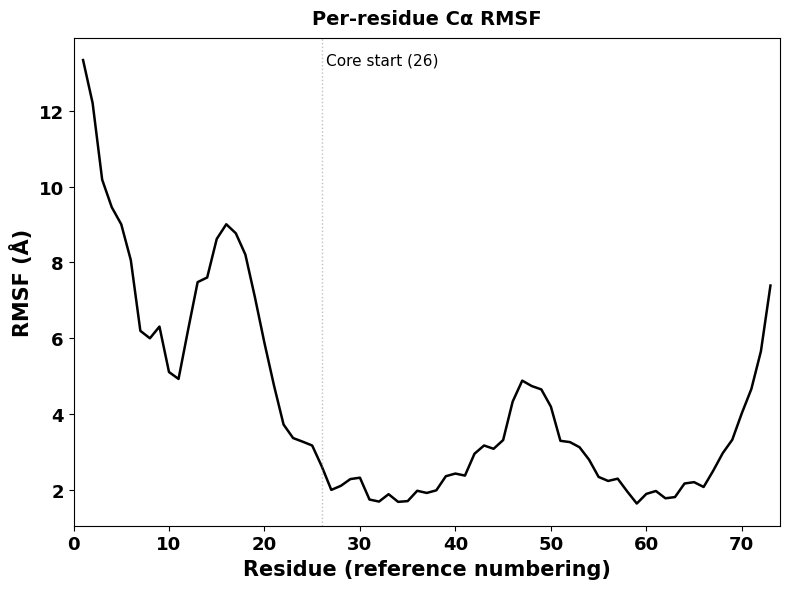

✓ remd_rmsf.png


In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(ca_resids_ref, rmsf, color="black", linewidth=1.8)

ax.axvline(CORE_START_REF, color="gray", ls=":", lw=1, alpha=0.5)
ax.annotate(f"Core start ({CORE_START_REF})",
            (CORE_START_REF, ax.get_ylim()[1] * 0.95),
            fontsize=11, ha="left", xytext=(3, 0), textcoords="offset points")

ax.set_xlabel("Residue (reference numbering)", fontsize=15)
ax.set_ylabel("RMSF (Å)",                   fontsize=15)
ax.tick_params(labelsize=13)
ax.set_title("Per-residue Cα RMSF", fontsize=14, pad=10)
ax.set_xlim(ca_resids_ref[0] - 1, ca_resids_ref[-1] + 1)

bold_ticks(ax)
plt.tight_layout()
plt.savefig(f"{OUT_PREFIX}_rmsf.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"✓ {OUT_PREFIX}_rmsf.png")


## 6. Equilibration — full backbone

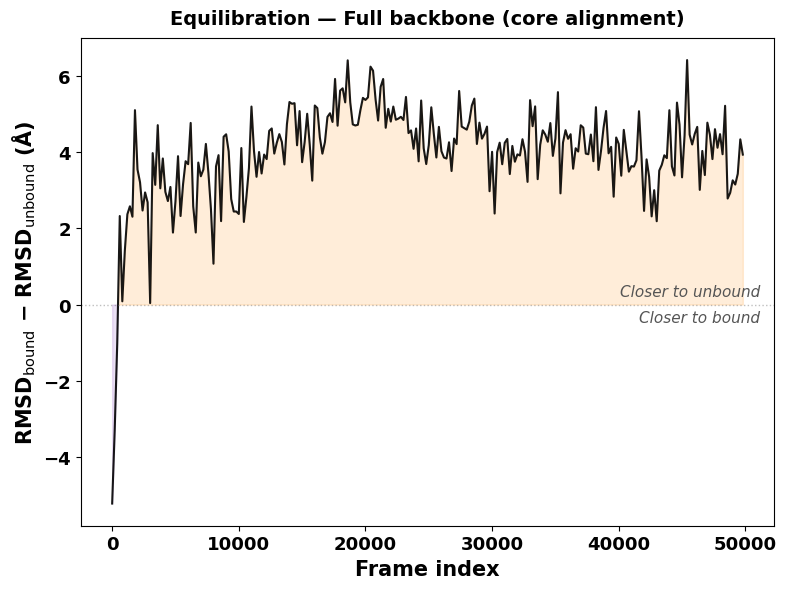

  Saved remd_equilibration_full.png


In [11]:
plot_equilibration("all", "Full backbone",
                   savename=f"{OUT_PREFIX}_equilibration_full.png")


## 7. Equilibration — core

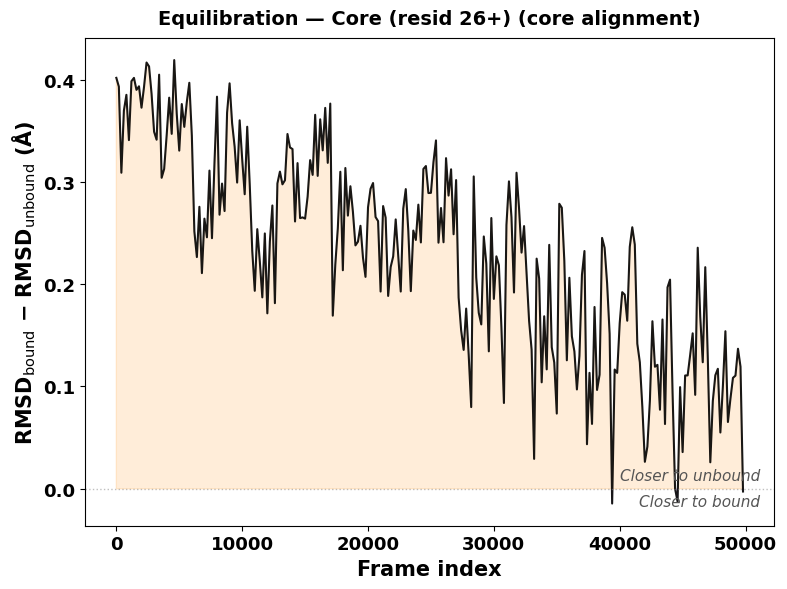

  Saved remd_equilibration_core.png


In [12]:
plot_equilibration("core", f"Core (resid {CORE_START_REF}+)",
                   savename=f"{OUT_PREFIX}_equilibration_core.png")


## 8. Equilibration — N-terminal

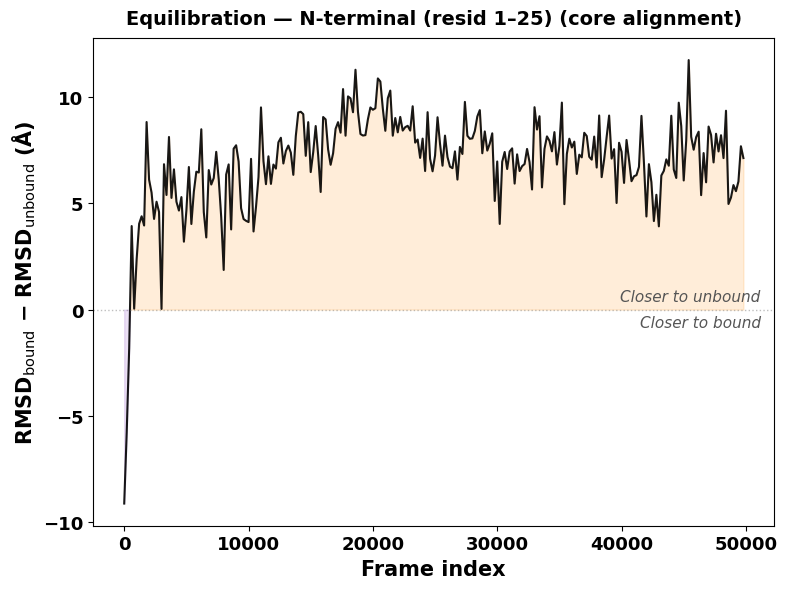

  Saved remd_equilibration_nterm.png


In [13]:
plot_equilibration("nterm", f"N-terminal (resid 1–{CORE_START_REF - 1})",
                   savename=f"{OUT_PREFIX}_equilibration_nterm.png")


## 9. Build core-aligned Cα feature matrix

The mean-aligned `ca_pos` from §4 is re-aligned using a **core-only Kabsch** (3 iterations against the running mean of core atoms). The full backbone Cα positions, after this re-alignment, are flattened into a feature vector per frame for k-means.

In [16]:
core_ca_mask = ca_resids_ref >= CORE_START_REF
print(f"Core Cα atoms: {core_ca_mask.sum()} of {n_ca}")

ca_full = ca_pos.copy()
ca_core = ca_full[:, core_ca_mask, :].copy()
mean_core = ca_core.mean(axis=0)

for it in range(3):
    aligned_full = np.zeros_like(ca_full)
    for j in range(n_eq):
        mob_core   = ca_full[j, core_ca_mask, :]
        mob_center = mob_core.mean(axis=0)
        ref_center = mean_core.mean(axis=0)
        H = (mob_core - mob_center).T @ (mean_core - ref_center)
        U, S, Vt = np.linalg.svd(H)
        d = np.sign(np.linalg.det(Vt.T @ U.T))
        R = Vt.T @ np.diag([1, 1, d]) @ U.T
        aligned_full[j] = (ca_full[j] - mob_center) @ R.T
    ca_full = aligned_full
    mean_core = ca_full[:, core_ca_mask, :].mean(axis=0)

ca_features = ca_full.reshape(n_eq, -1)
print(f"Core-aligned feature matrix: {ca_features.shape}")


Core Cα atoms: 48 of 73
Core-aligned feature matrix: (45000, 219)


## 10. K-means clustering and ordering

`K_CHOSEN` clusters (set in the configuration cell). Clusters are renumbered by ascending mean RMSD-to-bound, so cluster 1 is the most bound-like and the last cluster is the most unbound-like.

In [17]:
km = KMeans(n_clusters=K_CHOSEN, random_state=42, n_init=10)
raw_labels = km.fit_predict(ca_features)

# Order clusters by mean full-backbone RMSD-to-bound
rmsd_bound_eq = ga_data["bound_all"][eq_mask]
mean_rmsd     = {cl: rmsd_bound_eq[raw_labels == cl].mean() for cl in range(K_CHOSEN)}
sorted_cl     = sorted(mean_rmsd, key=mean_rmsd.get)
remap         = {old: new for new, old in enumerate(sorted_cl)}
labels        = np.array([remap[l] for l in raw_labels])
counts        = Counter(labels)

max_pop = max(counts.values()) / n_eq

print(f"\n{'Cluster':>10} {'Pop':>7} {'ΔG':>8}   "
      f"{'full(b/u)':>12} {'core(b/u)':>12} {'nterm(b/u)':>12}")
for cl in sorted(counts):
    mask = labels == cl
    pct = counts[cl] / n_eq
    dG  = -kT * np.log(pct / max_pop)
    bf, af = ga_data["bound_all"  ][eq_mask][mask].mean(), ga_data["alone_all"  ][eq_mask][mask].mean()
    bc, ac = ga_data["bound_core" ][eq_mask][mask].mean(), ga_data["alone_core" ][eq_mask][mask].mean()
    bn, an = ga_data["bound_nterm"][eq_mask][mask].mean(), ga_data["alone_nterm"][eq_mask][mask].mean()
    print(f"  Cluster {cl + 1:>2d} {pct:>6.1%} {dG:>7.2f}    "
          f"{bf:.1f}/{af:.1f}      {bc:.1f}/{ac:.1f}      {bn:.1f}/{an:.1f}")



   Cluster     Pop       ΔG      full(b/u)    core(b/u)   nterm(b/u)
  Cluster  1   9.4%    0.63    7.6/10.2      2.9/2.6      12.3/17.0
  Cluster  2  10.4%    0.57    9.8/7.1      3.6/3.8      15.9/10.9
  Cluster  3  17.9%    0.24    11.1/7.9      1.9/1.6      18.8/13.3
  Cluster  4  26.9%   -0.00    11.4/4.2      2.8/2.5      19.1/6.3
  Cluster  5  12.5%    0.45    11.8/6.5      2.5/2.4      19.7/10.4
  Cluster  6  23.0%    0.09    12.1/7.8      2.4/2.2      20.4/13.0


## 11. Cluster scatter plot (full backbone RMSD plane)

Each frame is plotted at its (RMSD vs bound, RMSD vs unbound) coordinate, coloured by cluster (viridis). Black-outlined hollow circles mark cluster centroids. The red and blue markers on the axes show where the bound and unbound *references* fall on this plane — they sit on the `RMSD = 0` axes by definition.

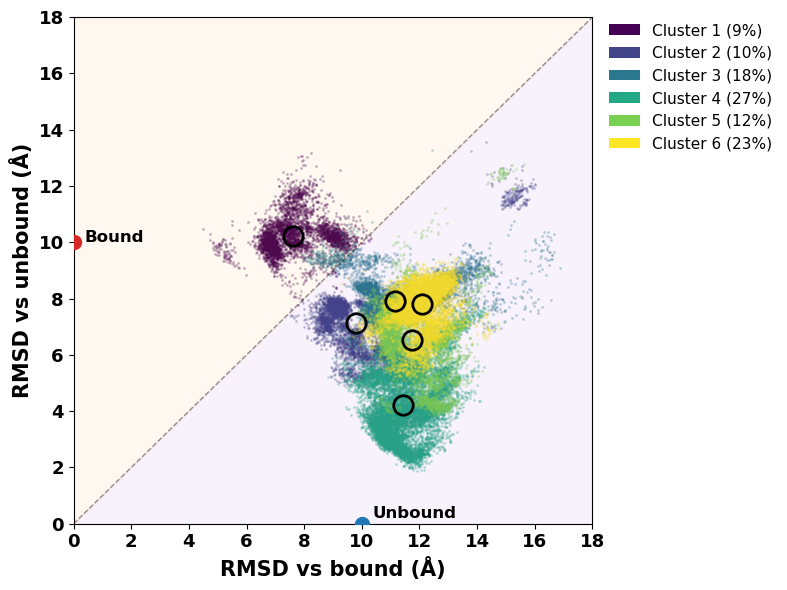

✓ remd_clusters.png


In [18]:
viridis = plt.cm.viridis
ccolors = {cl: viridis(cl / max(K_CHOSEN - 1, 1)) for cl in range(K_CHOSEN)}

# Reference-to-reference RMSD (full backbone)
rr_full = rms.rmsd(refs["alone_all"], refs["bound_all"],
                   center=True, superposition=True)

x = ga_data["bound_all"][eq_mask]
y = ga_data["alone_all"][eq_mask]

fig, ax = plt.subplots(figsize=(8, 6))

# Scatter (rasterized for compact PNG/PDF)
for cl in sorted(counts):
    cl_mask = labels == cl
    ax.scatter(x[cl_mask], y[cl_mask], c=[ccolors[cl]],
               s=1.5, alpha=0.2, rasterized=True)

# Centroids
for cl in sorted(counts):
    cl_mask = labels == cl
    cx, cy = x[cl_mask].mean(), y[cl_mask].mean()
    ax.plot(cx, cy, "o", markerfacecolor="none", markeredgecolor="black",
            markeredgewidth=2, markersize=14, zorder=5)

# Diagonal + half-plane shading
ax.set_xlim(0, 18); ax.set_ylim(0, 18)
ax.plot([0, 18], [0, 18], "k--", alpha=0.4, lw=1)
ax.fill_between([0, 18], [0, 18], [18, 18], alpha=0.06, color="#FF8C00")
ax.fill_between([0, 18], [0, 0],  [0, 18],  alpha=0.06, color="#7B2FBE")

# Reference markers
ax.plot(0, rr_full, "o", color="#d62728", markersize=10, zorder=6)
ax.annotate("Bound", (0, rr_full), fontsize=12, fontweight="bold", ha="left",
            xytext=(8, 0), textcoords="offset points")
ax.plot(rr_full, 0, "o", color="#1f77b4", markersize=10, zorder=6)
ax.annotate("Unbound", (rr_full, 0), fontsize=12, fontweight="bold", ha="left",
            xytext=(8, 4), textcoords="offset points")

ax.set_xlabel("RMSD vs bound (Å)",   fontsize=15)
ax.set_ylabel("RMSD vs unbound (Å)", fontsize=15)
ax.tick_params(labelsize=13)

legend_handles = [Patch(facecolor=ccolors[cl], edgecolor="none",
                        label=f"Cluster {cl + 1} ({100.0 * counts[cl] / n_eq:.0f}%)")
                  for cl in sorted(counts)]
ax.legend(handles=legend_handles, fontsize=11,
          loc="upper left", bbox_to_anchor=(1.02, 1.0),
          frameon=False, borderaxespad=0)

bold_ticks(ax)
plt.tight_layout()
plt.savefig(f"{OUT_PREFIX}_clusters.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"✓ {OUT_PREFIX}_clusters.png")


## 12. Representative PDBs

For each cluster the trajectory frame whose flattened core-aligned Cα vector is closest to the cluster centroid is chosen as the representative. Two PDBs are written per cluster: one with backbone atoms only (small, suitable for overlay) and one with all atoms (for PyMOL visualization).

In [19]:
eq_indices = np.where(eq_mask)[0]
write_sel  = SELS["traj_all"]

rep_frames = {}
print(f"\n{'Cluster':>10} {'Frame':>8}   {'RMSD_bound':>11} {'RMSD_unbound':>13}")
print("─" * 50)
for cl in sorted(counts):
    cl_indices  = np.where(labels == cl)[0]
    cl_centroid = ca_features[cl_indices].mean(axis=0)
    dists       = np.linalg.norm(ca_features[cl_indices] - cl_centroid, axis=1)
    best_local  = cl_indices[dists.argmin()]
    frame_idx   = eq_indices[best_local]
    rep_frames[cl] = frame_idx

    bf = ga_data["bound_all"][frame_idx]
    af = ga_data["alone_all"][frame_idx]
    print(f"  Cluster {cl + 1:>2d} {frame_idx:>8d}   {bf:>10.2f}Å {af:>12.2f}Å")

# Write PDBs ────────────────────────────────────────────────────────────────
print("\nSaving backbone-only representatives...")
for cl, frame_idx in rep_frames.items():
    u.trajectory[frame_idx]
    pdb = f"{OUT_PREFIX}_cluster{cl + 1}_representative.pdb"
    u.select_atoms(write_sel).write(pdb)
    pct = 100.0 * counts[cl] / n_eq
    print(f"  Cluster {cl + 1} ({pct:.0f}%): {pdb}")

print("\nSaving all-atom representatives...")
for cl, frame_idx in rep_frames.items():
    u.trajectory[frame_idx]
    pdb = f"{OUT_PREFIX}_cluster{cl + 1}_representative_allatom.pdb"
    u.atoms.write(pdb)
    print(f"  Cluster {cl + 1}: {pdb}")

print("\nDone! Load in PyMOL:")
print(f"  pymol {OUT_PREFIX}_cluster*_representative_allatom.pdb")



   Cluster    Frame    RMSD_bound  RMSD_unbound
──────────────────────────────────────────────────
  Cluster  1    15686         6.41Å         9.82Å
  Cluster  2    28840         9.31Å         6.96Å
  Cluster  3    12701        11.05Å         7.66Å
  Cluster  4    14947        11.08Å         2.98Å
  Cluster  5    45592        11.22Å         6.27Å
  Cluster  6    10659        11.96Å         7.94Å

Saving backbone-only representatives...
  Cluster 1 (9%): remd_cluster1_representative.pdb


/home/dbritton/miniforge3/envs/rla/lib/python3.9/site-packages/MDAnalysis/coordinates/PDB.py:1153: UserWarning: Found no information for attr: 'formalcharges' Using default value of '0'
  warnings.warn("Found no information for attr: '{}'"


  Cluster 2 (10%): remd_cluster2_representative.pdb
  Cluster 3 (18%): remd_cluster3_representative.pdb
  Cluster 4 (27%): remd_cluster4_representative.pdb
  Cluster 5 (12%): remd_cluster5_representative.pdb
  Cluster 6 (23%): remd_cluster6_representative.pdb

Saving all-atom representatives...
  Cluster 1: remd_cluster1_representative_allatom.pdb
  Cluster 2: remd_cluster2_representative_allatom.pdb
  Cluster 3: remd_cluster3_representative_allatom.pdb
  Cluster 4: remd_cluster4_representative_allatom.pdb
  Cluster 5: remd_cluster5_representative_allatom.pdb
  Cluster 6: remd_cluster6_representative_allatom.pdb

Done! Load in PyMOL:
  pymol remd_cluster*_representative_allatom.pdb


## 13. Cluster scatter plot (core and n-temrinal)

Each frame is plotted at its (RMSD vs bound, RMSD vs unbound) coordinate, coloured by cluster (viridis). Black-outlined hollow circles mark cluster centroids. The red and blue markers on the axes show where the bound and unbound *references* fall on this plane — they sit on the `RMSD = 0` axes by definition.

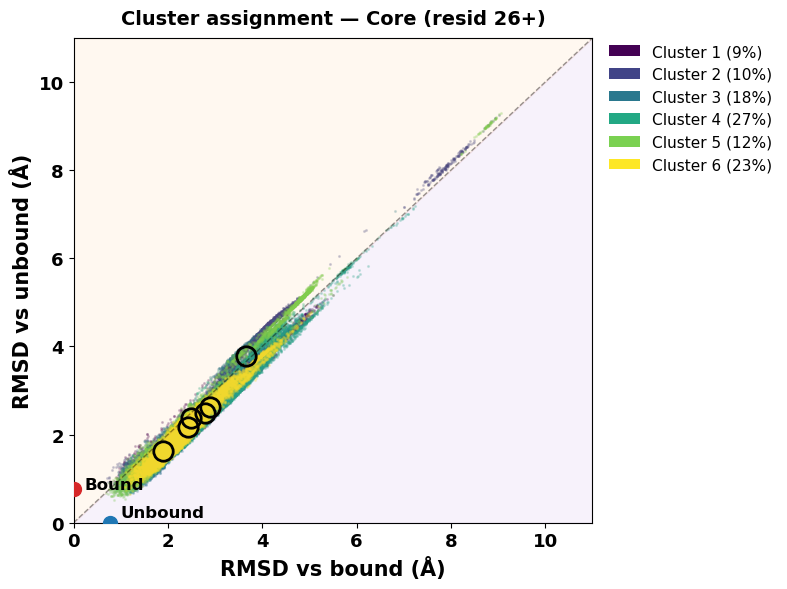

✓ remd_clusters_core.png


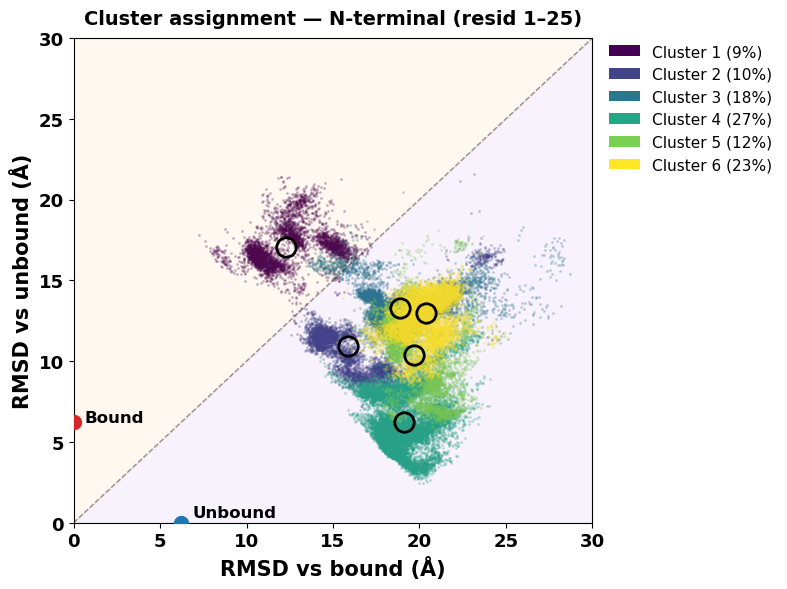

✓ remd_clusters_nterm.png


In [22]:
# ══════════════════════════════════════════════════════════════════════════════
# §15. Cluster scatter plots — core and N-terminal
# Same cluster labels as §13 (clustering done on full-backbone Cα features),
# projected onto each per-region RMSD plane.
# ══════════════════════════════════════════════════════════════════════════════

REGION_TITLES = {
    "core":  f"Core (resid {CORE_START_REF}+)",
    "nterm": f"N-terminal (resid 1\u2013{CORE_START_REF - 1})",
}

for region, title in REGION_TITLES.items():
    x = ga_data[f"bound_{region}"][eq_mask]
    y = ga_data[f"alone_{region}"][eq_mask]

    # Reference-to-reference RMSD for this region
    rr = rms.rmsd(refs[f"alone_{region}"], refs[f"bound_{region}"],
                  center=True, superposition=True)

    # Adaptive plot range (round up so axes have a bit of headroom)
    xy_max = float(np.ceil(max(x.max(), y.max(), rr) + 1))

    fig, ax = plt.subplots(figsize=(8, 6))

    # Scatter (rasterized for compact PNG/PDF)
    for cl in sorted(counts):
        cl_mask = labels == cl
        ax.scatter(x[cl_mask], y[cl_mask], c=[ccolors[cl]],
                   s=1.5, alpha=0.2, rasterized=True)

    # Centroids
    for cl in sorted(counts):
        cl_mask = labels == cl
        cx, cy = x[cl_mask].mean(), y[cl_mask].mean()
        ax.plot(cx, cy, "o", markerfacecolor="none", markeredgecolor="black",
                markeredgewidth=2, markersize=14, zorder=5)

    # Diagonal + half-plane shading
    ax.set_xlim(0, xy_max); ax.set_ylim(0, xy_max)
    ax.plot([0, xy_max], [0, xy_max], "k--", alpha=0.4, lw=1)
    ax.fill_between([0, xy_max], [0, xy_max], [xy_max, xy_max],
                    alpha=0.06, color="#FF8C00")
    ax.fill_between([0, xy_max], [0, 0], [0, xy_max],
                    alpha=0.06, color="#7B2FBE")

    # Reference markers
    ax.plot(0, rr, "o", color="#d62728", markersize=10, zorder=6)
    ax.annotate("Bound", (0, rr), fontsize=12, fontweight="bold", ha="left",
                xytext=(8, 0), textcoords="offset points")
    ax.plot(rr, 0, "o", color="#1f77b4", markersize=10, zorder=6)
    ax.annotate("Unbound", (rr, 0), fontsize=12, fontweight="bold", ha="left",
                xytext=(8, 4), textcoords="offset points")

    ax.set_xlabel("RMSD vs bound (\u00c5)",   fontsize=15)
    ax.set_ylabel("RMSD vs unbound (\u00c5)", fontsize=15)
    ax.tick_params(labelsize=13)
    ax.set_title(f"Cluster assignment \u2014 {title}", fontsize=14, pad=10)

    legend_handles = [Patch(facecolor=ccolors[cl], edgecolor="none",
                            label=f"Cluster {cl + 1} ({100.0 * counts[cl] / n_eq:.0f}%)")
                      for cl in sorted(counts)]
    ax.legend(handles=legend_handles, fontsize=11,
              loc="upper left", bbox_to_anchor=(1.02, 1.0),
              frameon=False, borderaxespad=0)

    bold_ticks(ax)
    plt.tight_layout()
    fname = f"{OUT_PREFIX}_clusters_{region}.png"
    plt.savefig(fname, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"\u2713 {fname}")